# A simple isothermal firn compaction model

## 1. Introduction
This notebook demonstrates how to run and plot results from a python version of the simple Eulerian, isothermal firn compaction model presented in 

Kingslake, J., Skarbek, R., Case, E., and McCarthy, C.: Grain-size evolution controls the accumulation dependence of modeled firn thickness, The Cryosphere Discuss. [preprint], https://doi.org/10.5194/tc-2022-13, in review, 2022.

In that paper (currently in review) the model is solved in Matlab. The code for solving the model equations with the Method of Lines (MOL) and plotting all the figures in matlab can be found [here](https://github.com/ldeo-glaciology/firn_accumulation_model). In the interest of sharing the model as widely as possible, there is now a python version of the code, which solves exactly the same equations, also using the MOL. The python version can be found [here](https://github.com/ldeo-glaciology/firn_accumulation_model/tree/main/python) (along with this notebook). 

This notebook summarizes the model, then demonstrates how to use the python code to solve the equations. 

## 2. The model
Refer to the paper cited above for the full details of the model derivation. Here we will summarize it so users get some familiarity with the physics and the variables being solved for. 

The model simulates a one-dimensional column of firn - the intermediate substance between snow and glacial ice - undergoing compaction under its own weight. It uses an Eulerian grid, i.e. a grid that stays stationary relative to the ice-sheet surface as the firn moves past it. 

### 2.1. Equations
The model describes the temporal and spatial evolution of five quantities, porosity $\phi$, pressure $\sigma$, velocity $w$, grain size $r^2$, age $A$, in one spatial dimension, along with the temporal evolution of the domain height $h$, which evolves as the ice-sheet surface moves up and down. The coupled evolution of these quantities is described by the following coupled partial differential equations:

\begin{equation} \label{eq:EvPhiND_h}
  \frac{\partial \phi}{\partial t} = \frac{1}{h} \frac{\partial}{\partial \hat{z}} \left[ (1 - \phi) w \right] + \left( \frac{\dot{h} \hat{z}}{h} \right) \frac{\partial \phi}{\partial \hat{z}} \;,
\end{equation}

\begin{equation}
  \label{eq:sigmaND_h}
  \frac{\partial \sigma}{\partial \hat{z}} = -h (1 - \phi) \;,
\end{equation}

\begin{equation}
  \label{eq:wevolveND_h}
  \frac{\partial w}{\partial \hat{z}}  = -\frac{h}{\alpha} \frac{|\sigma|^n \phi^{m}}{r^{2}}  \;,
\end{equation}

\begin{equation}
  \label{eq:Evr2ND_h}
  \frac{\partial r^{2}}{\partial t}  = \left( \frac{\dot{h} \hat{z} - w}{h} \right) \frac{\partial r^{2}}{\partial \hat{z}} + (1 - \delta r^{2})  \;,
\end{equation}

\begin{equation}
  \label{eq:EvAND_h}
    \frac{\partial A}{\partial t}  = 1 + \left( \frac{\dot{h} \hat{z} - w}{h} \right) \frac{\partial A}{\partial \hat{z}} \;,
\end{equation}

\begin{equation}
  \label{eq:Ev_h_ND_h}
  \frac{\partial h}{\partial t} = w(z_b) - \frac{\beta}{1 - \phi_b} \;.
\end{equation}



$\hat{z}$ is scaled depth, which varies between 0 at the surface and 1 at the bottom of the model domain, $z_b$, $t$ is time, $\alpha$ is a non-dimensional group of parameters/constants, $n$ and $m$ are constants with default values of 1, $\delta$ is a small nondimensional parameter, and $\beta$ is the nondimensional accumulation rate in ice-equivelent depth. 

The first equation describes how porosity varies due to compaction and advection. The second equation describes how pressure varies with depth. The third equation describes how the compaction rate is dictated by the pressure, porosity, and grain size. The fourth equation describes how the grain size evolves through 'normal grain growth' and advection. The fifth equation describes how the age of the firn evolves according to time passing and advection. The sixth equation describes how the height of the domain varies due to mismatch between the accumulation rate and the flow of firn out of the bottom of the domain. 

The equations have been nondimensionalized and scaled to take into account the effect of the changing length of the domain on the variables. 

### 2.2. Boundary conditions
Porosity and grain size are prescribed at the surface ($\phi_s$ and $r^2_s$, respectively), age and pressure are assumed to be zero at the surface, and velocity is prescribed at the surface as $$w_s = \frac{\beta}{(1-\phi_s)}$$.

### 2.3. Numerics
The code uses the Method Of Lines to solve these six coupled equations. A description of the method is given in the paper cited above. Also scholarpedia has a thorough article on the topic [here](http://www.scholarpedia.org/article/Method_of_lines): Samir Hamdi et al. (2007) Method of lines. Scholarpedia, 2(7):2859.


## 3. Code demostration
### 3.1. Import
The code is packaged with a few simple methods for running parameter searches in a python class called `fcm`, standing for firn compaction model, in a file called `fcm.py`. This is in the same github repo as this notebook, so assuming you either simply cloned the repo, are using this notebook after following the binder link, or downloaded the two files and they sit in the same directory, you can import the class using 

In [3]:
import sys
sys.path.insert(0, "..")
from main import FirnModel


We will also be using xarray, so let's import that and tell it not to show all the attributes every time you display a dataset: 

In [4]:
import xarray as xr

### 3.2. Run the code with default parameters

To run the code with default model parameters you first setup an instance of the `fcm` class (no inputs are required because we are using the built-in default values for all parameters). Then you run the model using the method `run()`:

In [6]:
fs = FirnModel()    # fs for firn simulations
fs.setup().run()

*** Starting setup.
*** Setup complete.
*** Starting integration.
*** Successfully finished integration in  0.228 seconds.
*** Post-processing.


<xarray.Dataset> Size: 999kB
Dimensions:       (z_h: 101, t: 175)
Coordinates:
  * z_h           (z_h) float64 808B 0.0 0.01 0.02 0.03 ... 0.97 0.98 0.99 1.0
  * t             (t) float64 1kB 0.0 0.01585 0.0306 0.04879 ... 3.974 3.996 4.0
    z             (z_h, t) float64 141kB 0.0 0.0 0.0 0.0 ... 0.874 0.874 0.874
Data variables:
    phi           (z_h, t) float64 141kB 0.5 0.5 0.5 ... 0.0002885 0.0002885
    r2            (z_h, t) float64 141kB 0.02857 0.02857 ... 0.7542 0.7542
    rho           (z_h, t) float64 141kB 459.0 459.0 459.0 ... 917.7 917.7 917.7
    A             (z_h, t) float64 141kB 0.0 0.0 0.0 ... 0.7519 0.7519 0.7519
    T             (z_h, t) float64 141kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    w             (z_h, t) float64 141kB 2.0 2.0 2.0 2.0 2.0 ... 1.0 1.0 1.0 1.0
    h             (t) float64 1kB 1.0 0.9914 0.9833 0.9731 ... 0.874 0.874 0.874
    M             (t) float64 1kB 75.0 75.0 75.0 75.0 ... 74.97 74.97 74.97
    FAC           (t) float64 1kB 25.0 24.14 23.33 22.31 ... 12.43 12.43 12.43
    z830          (t) float64 1kB 0.8083 0.7927 0.7766 ... 0.3626 0.3627 0.3627
    nu            (t) float64 1kB 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
    elapsed_time  float64 8B 0.2284
Attributes:
    simulation_parameters:  {'sim_label': 'default_label', 'b0_mpy': 0.1, 'be...

Model results are written to an xarray.dataset called `results` with data variables corresponding to the model variables and a few other derived quantities. This dataset is stored as an attribute of the class, so you can access it with

In [8]:
fs.results

<xarray.Dataset> Size: 999kB
Dimensions:       (z_h: 101, t: 175)
Coordinates:
  * z_h           (z_h) float64 808B 0.0 0.01 0.02 0.03 ... 0.97 0.98 0.99 1.0
  * t             (t) float64 1kB 0.0 0.01585 0.0306 0.04879 ... 3.974 3.996 4.0
    z             (z_h, t) float64 141kB 0.0 0.0 0.0 0.0 ... 0.874 0.874 0.874
Data variables:
    phi           (z_h, t) float64 141kB 0.5 0.5 0.5 ... 0.0002885 0.0002885
    r2            (z_h, t) float64 141kB 0.02857 0.02857 ... 0.7542 0.7542
    rho           (z_h, t) float64 141kB 459.0 459.0 459.0 ... 917.7 917.7 917.7
    A             (z_h, t) float64 141kB 0.0 0.0 0.0 ... 0.7519 0.7519 0.7519
    T             (z_h, t) float64 141kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    w             (z_h, t) float64 141kB 2.0 2.0 2.0 2.0 2.0 ... 1.0 1.0 1.0 1.0
    h             (t) float64 1kB 1.0 0.9914 0.9833 0.9731 ... 0.874 0.874 0.874
    M             (t) float64 1kB 75.0 75.0 75.0 75.0 ... 74.97 74.97 74.97
    FAC           (t) float64 1kB 25.0 24.14 23.33 22.31 ... 12.43 12.43 12.43
    z830          (t) float64 1kB 0.8083 0.7927 0.7766 ... 0.3626 0.3627 0.3627
    nu            (t) float64 1kB 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
    elapsed_time  float64 8B 0.2284
Attributes:
    simulation_parameters:  {'sim_label': 'default_label', 'b0_mpy': 0.1, 'be...

The displayed information shows that the dataset has two dimensions, the scaled depth, `z_h` ($\hat z$ in the equations above) and time `t`. These dimensions have values stored in the corresponding coordinates `z_h` and `t`. How the scaled depth `z_h` corresponds to true depth changes throughout the simulation because the domain height changes over time. There is an additional coordinate `z` which is the depth, computed by taking account of the time varying domain height `h`. More details on this below

There are data variables for our 6 coupled variables. Note that each of these except `h` is a function of `z_h` and `t`. The code also computes the firn air content `FAC`, the depth to 830 kg/m$^2$ (i.e. the firn thickness) `z830`, and the total mass in the firn column `M`. These are all functions only of `t`. Note that there is also a place-holder for the temperature `T` expressed as a deviation from the surface temperature. As this version of the model is isothermal, `T[:] = 0` and `T` has no effect on the simulation.

### 3.3. Simple plotting
#### 3.3.1. Using xarray's plotting tools. 
We can now use xarray's convenient plotting capabilities to examine these results. For example, let's plot a profile of porosity from the end of the simulation:

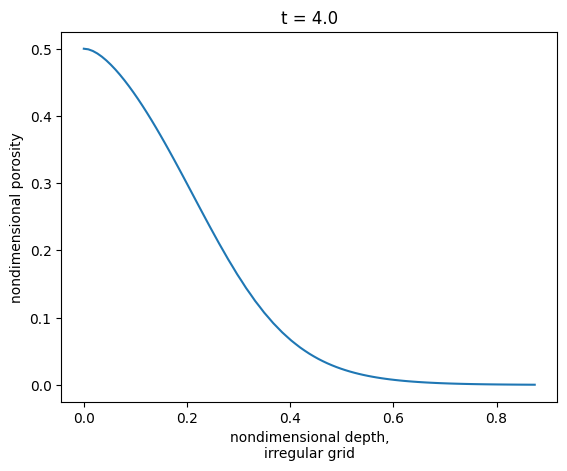

In [9]:
fs.results.phi.isel(t=-1).plot(x='z');

or the time variation of the firn air content `FAC` and firn thickness `h`:

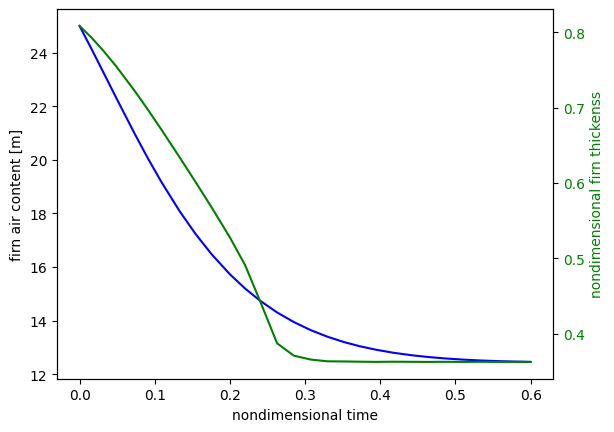

In [10]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

fs.results.FAC.sel(t=slice(0,0.6)).plot.line('b-', ax = ax1)
ax2 = ax1.twinx()  

fs.results.z830.sel(t=slice(0,0.6)).plot.line('g-', ax = ax2);
ax2.yaxis.label.set_color('g')
ax2.tick_params(axis='y', labelcolor='green')

#### 3.3.2. Interactive plots with hvplot

The hvplot package allows us to make interactive plots. For example, let's plot profiles of porosity (with respect to the scaled depth `z_h`) in a way that allows the user to select the time using a slider:

In [12]:
import hvplot.xarray  
fs.results.phi.sel(t=slice(0,0.6)).hvplot.line(x='z_h')

BokehModel(combine_events=True, render_bundle={'docs_json': {'bbd0d71e-3fc5-408f-98bd-d659c1843d8e': {'version…

One thing that is important to note about this plot is that it shows `phi` relative to the scaled, nondimensional depth, `z_h`. As mentioned above, how `z_h` corresponds to true depth changes throughout the simulation because the domain height changes over time. So, as you change the time step being displayed, the depth scale is changing in a way that is not visible in a plot like this. The next section remedies this by interpolating variables onto a regular depth grid. 

### 3.4. Interpolating to a regular vertical grid

For a number of reasons it is convenient to have model variables on a regular depth grid - i.e. one that does not change with `t`. For example, if you want to plot the time variation of a variable at a particular depth, or if you want to more easily compare profiles from different times. 

`interp_regular_z` does this for individual variables. You pass this function the name of the variable you want on a regular grid and it adds this variables to the `results` dataset with a '_r' suffix. It also adds the regular grid as a dimension coordinate named `z_r`:

In [13]:
fs.interp_regular_z(var_name = 'w')
fs.results

<xarray.Dataset> Size: 1MB
Dimensions:       (z_h: 101, t: 175, z_r: 121)
Coordinates:
  * z_h           (z_h) float64 808B 0.0 0.01 0.02 0.03 ... 0.97 0.98 0.99 1.0
  * t             (t) float64 1kB 0.0 0.01585 0.0306 0.04879 ... 3.974 3.996 4.0
    z             (z_h, t) float64 141kB 0.0 0.0 0.0 0.0 ... 0.874 0.874 0.874
  * z_r           (z_r) float64 968B 0.0 0.01 0.02 0.03 ... 1.17 1.18 1.19 1.2
Data variables: (12/13)
    phi           (z_h, t) float64 141kB 0.5 0.5 0.5 ... 0.0002885 0.0002885
    r2            (z_h, t) float64 141kB 0.02857 0.02857 ... 0.7542 0.7542
    rho           (z_h, t) float64 141kB 459.0 459.0 459.0 ... 917.7 917.7 917.7
    A             (z_h, t) float64 141kB 0.0 0.0 0.0 ... 0.7519 0.7519 0.7519
    T             (z_h, t) float64 141kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    w             (z_h, t) float64 141kB 2.0 2.0 2.0 2.0 2.0 ... 1.0 1.0 1.0 1.0
    ...            ...
    M             (t) float64 1kB 75.0 75.0 75.0 75.0 ... 74.97 74.97 74.97
    FAC           (t) float64 1kB 25.0 24.14 23.33 22.31 ... 12.43 12.43 12.43
    z830          (t) float64 1kB 0.8083 0.7927 0.7766 ... 0.3626 0.3627 0.3627
    nu            (t) float64 1kB 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
    elapsed_time  float64 8B 0.2284
    w_r           (z_r, t) float64 169kB 2.0 2.0 2.0 2.0 2.0 ... nan nan nan nan
Attributes:
    simulation_parameters:  {'sim_label': 'default_label', 'b0_mpy': 0.1, 'be...

This allows us to easily compare profiles from different time steps:

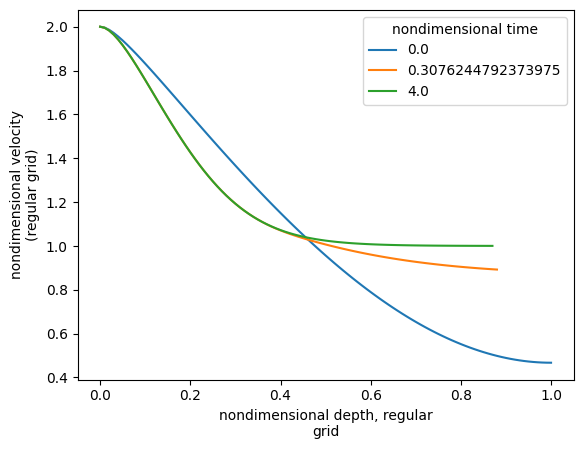

In [14]:
fs.results.w_r.sel(t=[0,0.3,4], method = 'nearest').plot.line(x='z_r');

...and make plots showing the depth and time variation of the variable as a color map:

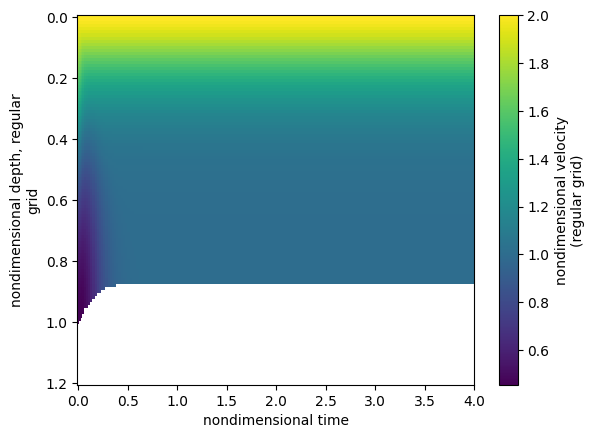

In [15]:
fs.results.w_r.plot(yincrease=False);

Notice that the shape of the colored region in the plot above reflects the fact that the domain started with a length of 1 ($h(0) = 1$), but decreased over time until it reached a steady value of:

In [16]:
fs.results.h[-1]

<xarray.DataArray 'h' ()> Size: 8B
array(0.87396102)
Coordinates:
    t        float64 8B 4.0
Attributes:
    name:         height
    long_name:    nondimensional domain height
    scale:        100
    scale_units:  m

Now, using hvplot we can make a useful comparison between `phi` at different time steps:

In [17]:
fs.interp_regular_z(var_name = 'phi')
fs.results.phi_r.sel(t=slice(0,0.6)).hvplot.line(x='z_r')

BokehModel(combine_events=True, render_bundle={'docs_json': {'12d23295-61c7-49d1-a721-0754e0852078': {'version…

Notice that the code `fs.results.phi_r.sel(t=slice(0,0.6)).hvplot.line(x='z_r')` is exactly the same as the previous call to hvplot, but the `z_h` has was replaced by `z_r` and `phi` was replaced `phi_r'.

Interpolation onto a regular grid can take a few seconds per variable, so we do not do this by default in the main model run, but you can turn this functionality on by passing `interp_on_reg_z = True` to `run()`.

### 3.5. Varying model parameters

To rerun the model with different model paramaters, pass them to `run()`. A full list of the parameters in is the table below.

| parameter | default value | description |
| --- | --- | --- |
`sim_label` |   `'default_label'` | A label for the simulation
`b0_mpy`    |   `0.1`             | the accumulation scale
`beta`      |   `1`               | the nondimensional accumulation rate
`nu`        |   `1`               | accccumulation multiplier used to simulate thinning/thickening
`T_s_dim`   |   `253.15`          | surface temperature
`dz`        |   `0.01`            | grid spacing
`sim_r`     |   `True`            | option to simulate grain size (True) or leave it unifrom and constnat (False)
`z0`        |   `100`             | depth scale
`r_s_dim`   |   `2.5000e-07`      | dimensional grain size at the surface, default corresponds to (0.5 mm)$^2$ 
`phi_s`     |   `0.5`             | porosity at the surface
`n`         |   `1`               | stress exponent in firn rheology
`simDuration`     |   `4`         | duration of the simulation
`scaleDuration`   |   `False`     | option to scale simulaion duration by the accumulation rate: simDuration/beta
`interp_on_reg_z` |   `False`     | option to interpolate all z-t variables onto a regular depth grid
`print_messages`  |   `True`      | option to print messages indicating progress

For example, to run the model with a higher accumulation rate use


In [21]:
fs_highBeta = FirnModel()
fs_highBeta.setup(beta=10).run()

*** Starting setup.
*** Setup complete.
*** Starting integration.
*** Successfully finished integration in  1.87 seconds.
*** Post-processing.


<xarray.Dataset> Size: 10MB
Dimensions:       (z_h: 101, t: 1728)
Coordinates:
  * z_h           (z_h) float64 808B 0.0 0.01 0.02 0.03 ... 0.97 0.98 0.99 1.0
  * t             (t) float64 14kB 0.0 0.00144 0.002786 ... 3.996 3.998 4.0
    z             (z_h, t) float64 1MB 0.0 0.0 0.0 0.0 ... 0.9989 0.9989 0.9989
Data variables:
    phi           (z_h, t) float64 1MB 0.5 0.5 0.5 ... 0.009133 0.009133
    r2            (z_h, t) float64 1MB 0.02857 0.02857 0.02857 ... 0.1034 0.1034
    rho           (z_h, t) float64 1MB 459.0 459.0 459.0 ... 909.6 909.6 909.6
    A             (z_h, t) float64 1MB 0.0 0.0 0.0 ... 0.07526 0.07526 0.07526
    T             (z_h, t) float64 1MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    w             (z_h, t) float64 1MB 20.0 20.0 20.0 20.0 ... 10.09 10.09 10.09
    h             (t) float64 14kB 1.0 1.012 1.023 ... 0.9989 0.9989 0.9989
    M             (t) float64 14kB 75.0 75.01 75.01 75.02 ... 75.02 75.02 75.02
    FAC           (t) float64 14kB 25.0 26.19 27.26 28.62 ... 24.87 24.87 24.87
    z830          (t) float64 14kB 0.8083 0.8327 0.8551 ... 0.6922 0.6922 0.6922
    nu            (t) float64 14kB 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
    elapsed_time  float64 8B 1.873
Attributes:
    simulation_parameters:  {'sim_label': 'default_label', 'b0_mpy': 0.1, 'be...

We can plot the results on the same figure without interpolating onto a regular grid if we only want to plot the final time step, becuase we can plot each against its respective `z`.

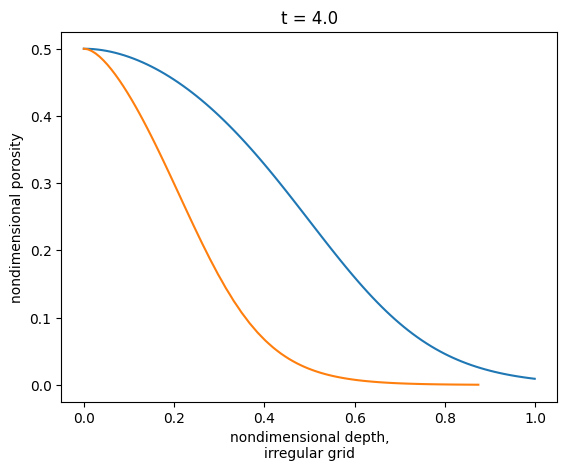

In [22]:
fs_highBeta.results.phi.sel(t=4).plot.line(x='z');
fs.results.phi.sel(t=4).plot.line(x='z');


### 3.6. Parameter search

A method called `param_search_1D()` automates a common procedure: a one-dimensional parameter search, i.e. runnning the model many times, each time changing one of the model paramters. Inputs to this method are the parameter you want to vary and the values you want to use. The method will loop over the values, running the model multiple times and saving the results in one large xarray.dataset with a new dimension corresponding to the parameter you chose to vary. Only the final times step is saved in each case.

In [23]:
import numpy as np
fs_1Dsearch = FirnModel()
fs_1Dsearch.param_search_1D(param_to_vary = 'beta', param_values = np.linspace(0.1, 5, 10), r_s_dim = 3.e-07)

AttributeError: 'FirnModel' object has no attribute 'param_search_1D'

Note that we can also chose non-default values of other parameters in the call to `param_search_1D`. Above we chose a larger surface grain size than the default value. 

In the resulting xarray.dataset all variables are now also a function of `beta` and `z_h`:

In [17]:
fs_1Dsearch.results

<xarray.Dataset>
Dimensions:  (beta: 10, z_h: 101)
Coordinates:
  * z_h      (z_h) float64 0.0 0.01 0.02 0.03 0.04 ... 0.96 0.97 0.98 0.99 1.0
    z        (beta, z_h) float64 0.0 0.008386 0.01677 ... 0.938 0.9475 0.9571
    t        float64 4.0
  * beta     (beta) float64 0.1 0.6444 1.189 1.733 ... 3.367 3.911 4.456 5.0
Data variables:
    phi      (beta, z_h) float64 0.5 0.4965 0.4882 ... 0.00415 0.003774 0.003431
    r2       (beta, z_h) float64 0.03428 0.07623 0.1187 ... 0.1796 0.1814 0.1833
    rho      (beta, z_h) float64 459.0 462.3 469.8 479.0 ... 914.2 914.5 914.9
    A        (beta, z_h) float64 0.0 0.04223 0.08515 ... 0.1467 0.1486 0.1505
    T        (beta, z_h) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    w        (beta, z_h) float64 0.2 0.1986 0.1954 0.1917 ... 5.021 5.019 5.017
    h        (beta) float64 0.8386 0.8672 0.8846 0.8987 ... 0.9406 0.9491 0.9571
    M        (beta) float64 74.96 74.97 74.97 74.98 ... 74.99 74.99 75.0 75.0
    FAC      (beta) float64 8.902 11.76 13.49 14.89 ... 18.15 19.06 19.91 20.71
    z830     (beta) float64 0.272 0.3453 0.3904 0.4268 ... 0.5368 0.5593 0.5806
Attributes: (1)

This dataset is in a convenient format for comparing across simulations with different `beta`s. For example, let's plot the final-timestep's `phi` profiles for each simulation, colored by `beta`:

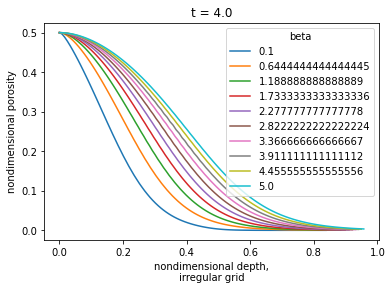

In [18]:
fs_1Dsearch.results.phi.plot.line(x='z', hue='beta');


...and let's plot the variation of firn thickness `z830` with `beta`

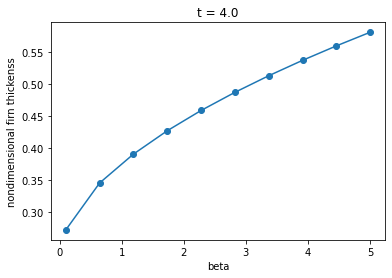

In [21]:
fs_1Dsearch.results.z830.plot(marker='o')

Note, that the reason only the final time step is saved from each simulation is that each simulation uses a different time step (chosen dynamically by a scipy ODE solver) so interpolation would be required to put the results on a regular temporal grid.

## 4. Summary

The key ways to run the model are summarized as follows:

| task | code | output/result |
| --- | --- | --- |
| initalize the model | `fs = fcm()` | an instance of the model stored in `fs` |
| run model with default parameters | `fs.run()` | the model runs and the results are stored in fs.results |
| run model with uder-defined parameters | `fs.run(beta = 0.3)` | the model runs and the results are stored in fs.results |
| interpolate results onto a regular grid  | `fs.interp_regular_z(var_name = 'phi')` | interpolated variables and regular grid are added to fs.results |
| performa 1D parameter search | `fs.param_search_1D(param_to_vary = 'beta', param_values = np.linspace(0.1, 5, 10))` | the model runs multiple times and the results are added to fs.results along a dimension corresonding to the search parameter  |


To do items include:

- adapt param_search_1D to allow searches over an arbirtary number of dimensions, 
- interpolate output from parameters searches over space and time so that time series of variables can more easily be compared, 
- include dynamic temperature in the model. 

And feedback or edits are welcome. Please contribute through github: https://github.com/ldeo-glaciology/firn_accumulation_model